## Industrial Filter Predictive Maintenance

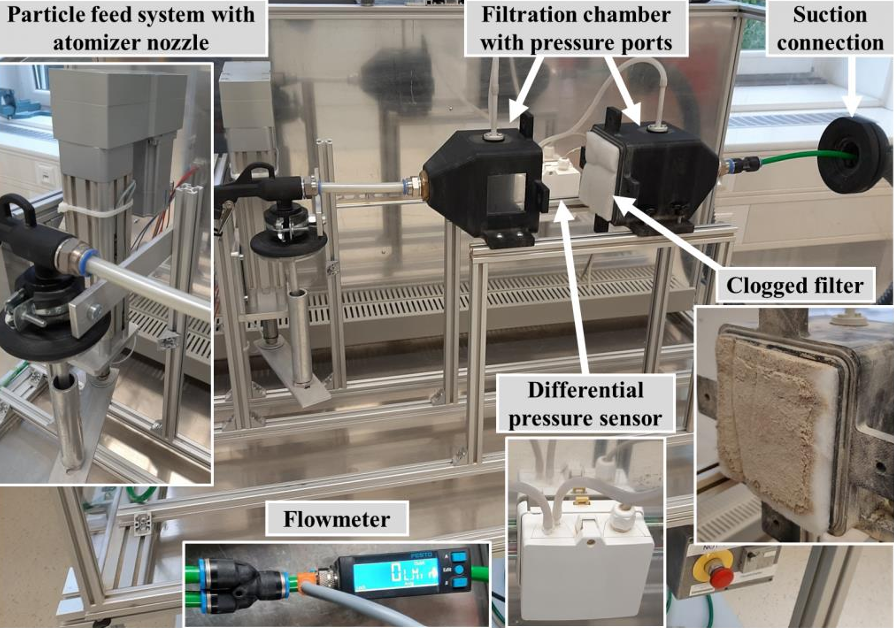

### Modeling

In this stage, machine learning models are trained using the engineered features to predict the Remaining Useful Life (RUL) of the filter. The goal is to evaluate how well the model can learn degradation patterns and generalize to unseen data.

#### Importing Dependencies

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Load Data

In [72]:
# Load processed training data
train = pd.read_csv('../Data/train_engineered_v2.csv')

# Load raw test dataset
test = pd.read_csv('../Data/Test_data.csv')

In [73]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (39420, 20)
Test Shape: (39414, 7)


,Data_No,Differential_pressure,Flow_rate,Time,Dust_feed,Dust,Dust_feed_group,Flow_group,max_time,RUL,pressure_rate,normalized_time,rolling_pressure_mean,pressure_ratio,rate_ratio_interaction,cumulative_pressure,pressure_acceleration,rolling_pressure_std,remaining_pressure_capacity,pressure_growth_rate
0,1,0.0,0.0,0.1,236.428943,"ISO 12103-1, A3 Medium Test Dust",High,Low,44.9,44.8,0.0,0.002227,0.0,0.0,0.0,0.0,0.0,0.0,600.0,0.0
1,1,0.0,0.0,0.2,236.428943,"ISO 12103-1, A3 Medium Test Dust",High,Low,44.9,44.7,0.0,0.004454,0.0,0.0,0.0,0.0,0.0,0.0,600.0,0.0
2,1,0.0,0.0,0.3,236.428943,"ISO 12103-1, A3 Medium Test Dust",High,Low,44.9,44.6,0.0,0.006682,0.0,0.0,0.0,0.0,0.0,0.0,600.0,0.0
3,1,0.0,0.0,0.4,236.428943,"ISO 12103-1, A3 Medium Test Dust",High,Low,44.9,44.5,0.0,0.008909,0.0,0.0,0.0,0.0,0.0,0.0,600.0,0.0
4,1,0.0,0.0,0.5,236.428943,"ISO 12103-1, A3 Medium Test Dust",High,Low,44.9,44.4,0.0,0.011136,0.0,0.0,0.0,0.0,0.0,0.0,600.0,0.0


In [74]:
test.head()

,Data_No,Differential_pressure,Flow_rate,Time,Dust_feed,Dust,RUL
0,1,0.271267,52.281993,0.1,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.9
1,1,0.361690,54.986671,0.2,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.8
2,1,0.000000,55.424786,0.3,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.7
3,1,2.622251,55.524146,0.4,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.6
4,1,3.888165,55.852018,0.5,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.5


In [75]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 39420 entries, 0 to 39419
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Data_No                      39420 non-null  int64  
 1   Differential_pressure        39420 non-null  float64
 2   Flow_rate                    39420 non-null  float64
 3   Time                         39420 non-null  float64
 4   Dust_feed                    39420 non-null  float64
 5   Dust                         39420 non-null  str    
 6   Dust_feed_group              39420 non-null  str    
 7   Flow_group                   39420 non-null  str    
 8   max_time                     39420 non-null  float64
 9   RUL                          39420 non-null  float64
 10  pressure_rate                39420 non-null  float64
 11  normalized_time              39420 non-null  float64
 12  rolling_pressure_mean        39420 non-null  float64
 13  pressure_ratio             

In [76]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 39414 entries, 0 to 39413
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data_No                39414 non-null  int64  
 1   Differential_pressure  39414 non-null  float64
 2   Flow_rate              39414 non-null  float64
 3   Time                   39414 non-null  float64
 4   Dust_feed              39414 non-null  float64
 5   Dust                   39414 non-null  str    
 6   RUL                    39414 non-null  float64
dtypes: float64(5), int64(1), str(1)
memory usage: 2.1 MB


#### Preprocessing Test Dataset

In [77]:
# Dust feed groups
test["Dust_feed_group"] = pd.cut(
    test["Dust_feed"],
    bins=[0, 100, 200, np.inf],
    labels=["Low", "Medium", "High"]
)

# Flow rate groups
test["Flow_group"] = pd.cut(
    test["Flow_rate"],
    bins=[0, 60, 75, np.inf],
    labels=["Low", "Medium", "High"]
)

# pressure rate of change
test["pressure_rate"] = (
    test.groupby("Data_No")["Differential_pressure"].diff()
    /
    test.groupby("Data_No")["Time"].diff()
)

test["pressure_rate"] = test["pressure_rate"].fillna(0)

# Time normalization (relative time)
max_time_test = test.groupby("Data_No")["Time"].max().reset_index()
max_time_test.columns = ["Data_No", "max_time"]

test = test.merge(max_time_test, on="Data_No")

test["normalized_time"] = test["Time"] / test["max_time"]

# Rolling mean of pressure
test["rolling_pressure_mean"] = (
    test.groupby("Data_No")["Differential_pressure"]
    .rolling(window=5)
    .mean()
    .reset_index(level=0, drop=True)
)

test["rolling_pressure_mean"] = test[
    "rolling_pressure_mean"
].fillna(0)

# Pressure ratio (current pressure / max pressure)
test["pressure_ratio"] = (
    test["Differential_pressure"] / 600
)

# Interaction feature: pressure rate * pressure ratio
test["rate_ratio_interaction"] = (
    test["pressure_rate"] *
    test["pressure_ratio"]
)

# Advanced feature

# Cumulative pressure 
test["cumulative_pressure"] = test.groupby("Data_No")[
    "Differential_pressure"
].cumsum()

# Pressure acceleration (second derivative)
test["pressure_acceleration"] = test.groupby("Data_No")[
    "pressure_rate"
].diff()

test["pressure_acceleration"] = test[
    "pressure_acceleration"
].fillna(0)

# Rolling standard deviation of pressure
test["rolling_pressure_std"] = (
    test.groupby("Data_No")["Differential_pressure"]
    .rolling(window=5)
    .std()
    .reset_index(level=0, drop=True)
)

test["rolling_pressure_std"] = test[
    "rolling_pressure_std"
].fillna(0)

# Remaining pressure capacity
test["remaining_pressure_capacity"] = (
    600 - test["Differential_pressure"]
)

# Pressure growth rate
test["pressure_growth_rate"] = (
    test["Differential_pressure"] /
    (test["Time"] + 1e-6)
)

In [91]:
# Saving the engineered test dataset
test.to_csv('../Data/test_engineered_v2.csv', index=False)

In [78]:
test.shape

(39414, 20)

In [79]:
test.head()

,Data_No,Differential_pressure,Flow_rate,Time,Dust_feed,Dust,RUL,Dust_feed_group,Flow_group,pressure_rate,max_time,normalized_time,rolling_pressure_mean,pressure_ratio,rate_ratio_interaction,cumulative_pressure,pressure_acceleration,rolling_pressure_std,remaining_pressure_capacity,pressure_growth_rate
0,1,0.271267,52.281993,0.1,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.9,High,Low,0.00000,36.6,0.002732,0.000000,0.000452,0.000000,0.271267,0.00000,0.000000,599.728733,2.712643
1,1,0.361690,54.986671,0.2,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.8,High,Low,0.90423,36.6,0.005464,0.000000,0.000603,0.000545,0.632957,0.90423,0.000000,599.638310,1.808441
2,1,0.000000,55.424786,0.3,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.7,High,Low,-3.61690,36.6,0.008197,0.000000,0.000000,-0.000000,0.632957,-4.52113,0.000000,600.000000,0.000000
3,1,2.622251,55.524146,0.4,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.6,High,Low,26.22251,36.6,0.010929,0.000000,0.004370,0.114603,3.255208,29.83941,0.000000,597.377749,6.555611
4,1,3.888165,55.852018,0.5,236.428943,"ISO 12103-1, A3 Medium Test Dust",58.5,High,Low,12.65914,36.6,0.013661,1.428675,0.006480,0.082035,7.143373,-13.56337,1.731537,596.111835,7.776314


#### Encoding Categorical Features

In [80]:
combined = pd.concat([train, test], axis=0)

combined = pd.get_dummies(
    combined,
    columns=["Dust", "Dust_feed_group", "Flow_group"],
    drop_first=True,
    dtype=int
)


train_encoded = combined.iloc[:len(train)]
test_encoded = combined.iloc[len(train):]

In [81]:
print(train_encoded.shape)
print(test_encoded.shape)

(39420, 23)
(39414, 23)


In [82]:
print(X_train.shape)
print(X_test.shape)

print(X_train.columns.equals(X_test.columns))

(39420, 20)
(39414, 20)
True


In [83]:
missing_in_test = set(X_train.columns) - set(X_test.columns)
missing_in_train = set(X_test.columns) - set(X_train.columns)

print("Missing in test:", missing_in_test)
print("Missing in train:", missing_in_train)

Missing in test: set()
Missing in train: set()


#### Model Build

In [84]:
X_train = train_encoded.drop(
    columns=[
        "RUL",
        "Data_No",
        "max_time",
        "Time"
    ],
    errors="ignore"
)

y_train = train_encoded["RUL"]


X_test = test_encoded.drop(
    columns=[
        "RUL",
        "Data_No",
        "max_time",
        "Time"
    ],
    errors="ignore"
)

y_test = test_encoded["RUL"]

In [85]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#### Evaluation

In [86]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

MAE: 53.56183956795423
MSE: 4312.4686227429365
R2 Score: 0.21544288597962546
RMSE: 65.66938878003157


#### - XGBoost

In [87]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

#### - XGBoost Evaluation

In [88]:
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_xgb))

MAE: 53.845993212854246
MSE: 4367.179955842899
R2 Score: 0.20548938385447546
RMSE: 66.08464235995304


#### Feature Importance

In [90]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=False).head(15)

normalized_time                          0.548076
Dust_feed                                0.265357
Dust_feed_group_Low                      0.138147
rolling_pressure_mean                    0.009149
pressure_growth_rate                     0.006951
cumulative_pressure                      0.006728
Dust_feed_group_Medium                   0.005692
Dust_ISO 12103-1, A3 Medium Test Dust    0.005155
remaining_pressure_capacity              0.004973
Dust_ISO 12103-1, A4 Coarse Test Dust    0.003680
Flow_rate                                0.002866
Differential_pressure                    0.001565
pressure_ratio                           0.001559
Flow_group_Low                           0.000076
Flow_group_Medium                        0.000012
dtype: float64

### Saving the Model

In [93]:
import joblib
joblib.dump(model, '../models/random_forest_model.pkl')

# Save feature columns
joblib.dump(X_train.columns.tolist(), '../models/model_features.pkl')

['../models/model_features.pkl']